# A personalized research podcast, powered by deep agents

<img src="./images/deepAgentsDiag.png" style="width: auto; height: 400px; border-radius: 8px;" alt="Deep Agents harness overview">

Over the next hour you'll build a research agent that reads the latest arXiv papers, files the ones you approve into a library that survives across sessions, and turns that library into a **podcast series** where each episode covers only what's new. The domain here is computational longevity (aging clocks, senescence, caloric restriction, biological-age ML), but the pattern works for any field.

Three threads run through the whole notebook:

- **Long-term memory** — the library outlives any single chat, and we *visualize it at every step* so you can see exactly what the agent stores and recalls.
- **Human-in-the-loop** — nothing enters the library without your approval.
- **Continuity** — because every episode is logged to memory, the podcast is a *series*: Episode 2 knows what Episode 1 already covered.

> Runs on the **free tier** of Google's Gemini API. You need a free `GOOGLE_API_KEY` ([aistudio.google.com/apikey](https://aistudio.google.com/apikey)) and a free `TAVILY_API_KEY` ([tavily.com](https://tavily.com)). See the README.

## ▶️ Running in Google Colab

Run the **setup cell below first** — it clones the repo, installs the workshop, and asks for two free API keys ([Google AI Studio](https://aistudio.google.com/apikey) and [Tavily](https://tavily.com)). Then run the notebook top to bottom.

> Tip: add `GOOGLE_API_KEY` and `TAVILY_API_KEY` to Colab **Secrets** (🔑 in the left sidebar) and the cell picks them up automatically — otherwise it prompts you to paste them.

In [ ]:
# ▶️ Run this first in Colab. Clones the repo, installs it, sets your API keys.
# (Running locally instead? This cell detects that and does nothing.)
import os, sys, subprocess

if "google.colab" in sys.modules and not os.path.exists("utils"):
    if not os.path.exists("deep-agents-podcast"):
        subprocess.run(
            ["git", "clone", "-q",
             "https://github.com/marta-langchain/deep-agents-podcast.git"],
            check=True,
        )
    os.chdir("deep-agents-podcast")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)

    from getpass import getpass
    for key in ("GOOGLE_API_KEY", "TAVILY_API_KEY"):
        if os.environ.get(key):
            continue
        try:
            from google.colab import userdata
            os.environ[key] = userdata.get(key)          # Colab Secrets (🔑)
        except Exception:
            os.environ[key] = getpass(f"{key} (free — see the README): ")

    # Optional: LangSmith tracing, if you've added LANGSMITH_API_KEY to Secrets.
    try:
        from google.colab import userdata
        os.environ["LANGSMITH_API_KEY"] = userdata.get("LANGSMITH_API_KEY")
        os.environ["LANGSMITH_TRACING"] = "true"
    except Exception:
        pass

    print("✅ Colab setup complete — working dir:", os.getcwd())

### Agenda (~60 min)

| Part | Topic | 
|---|---|
| 0 | Setup | 
| 1 | Your first deep agent (the harness) | 
| 2 | Custom tools (arXiv + web) | 
| 3 | Backends — who can see the files | 
| 4 | Research subagents | 
| 5 | Human-in-the-loop | 
| 6 | Long-term memory | 
| 7 | AGENTS.md & skills | 
| 8 | The podcast, with continuity |


**Free-tier heads-up.** A deep agent makes a lot of model calls. If you hit `429 RESOURCE_EXHAUSTED`, that's the per-project rate limit (~15 req/min) — wait a few seconds and re-run the cell. Each `agent.invoke(...)` can take 15–40s; that's normal.

## Part 0: Setup

The setup cell above already installed the workshop and set your keys. The model is configured in `utils/models.py` — Gemini `gemini-flash-lite-latest` on the free tier. The next cell imports the tools and memory visualizers we'll use throughout.

> **Optional — LangSmith.** Add `LANGSMITH_API_KEY` to Colab **Secrets** (🔑) before running the setup cell, and a 🔗 trace link appears under each run.

In [5]:
# Quick install if needed:
# !pip install -e .

import sys
from pathlib import Path
project_root = Path().resolve()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dotenv import load_dotenv
load_dotenv(override=True)

from IPython.display import Image   # to render agent graphs inline

from utils.models import model, sub_agent_model
from utils.memory import open_memory_store, MEMORY_NAMESPACE, DEFAULT_DB
from utils.viz import (
    show_memory,        # the durable library, read straight from the store
    show_library,       # a "shelf" view of what's been collected
    snapshot, render_diff,  # what changed in memory across an operation
    route_map,          # which backend handles which path
    show_architecture,  # capabilities + memory, lighting up part by part
    save_briefing,      # write a generated /briefing.md out to a real file
    trace_link,         # shows a LangSmith trace link when tracing is on
)

print("Ready — model:", getattr(model, "model", type(model).__name__))

Ready — model: gemini-flash-lite-latest


**Start clean (optional).** The next cell wipes any existing library so the demos are reproducible — run it once now. **Skip it if you restart the kernel to test persistence in Part 6**, or you'll erase the very library you're proving survives.

In [6]:
# Optional reset — wipe any existing on-disk library for a clean run.
# Do NOT run this after a kernel restart if you're testing Part 6 persistence.
for f in Path().glob(DEFAULT_DB + "*"):
    f.unlink()
print("Library reset — starting clean.")

Library reset — starting clean.


## Part 1: Your First Deep Agent (The Harness)

<img src="./images/deepAgentsHarnessOverview.png" style="width: auto; height: 400px; border-radius: 8px;" alt="Deep Agents harness">

Deep Agents is an **agent harness** — a tool-calling loop with capabilities baked in.

**Out of the box you get:**
- **Filesystem tools** — `ls`, `read_file`, `write_file`, `edit_file`, `glob`, `grep`
- **Planning tool** — `write_todos` for task tracking
- **Subagent delegation** — a `task()` tool for isolated work
- **Context management** — evicts large tool results to the filesystem, summarizes history near the context limit

These come from a stack of built-in middleware attached automatically by `create_deep_agent()`.

In [8]:
show_architecture(through="harness")

In [9]:
from deepagents import create_deep_agent

agent = create_deep_agent(model=model)  # simplest deep agent

# No custom tools yet — but the agent can already write and read files.
with trace_link("Part 1 — first run"):
    result = agent.invoke({
        "messages": [{"role": "user", "content":
            "Write /note.md with one line: 'Aging clocks estimate biological age from molecular data.' Then read it back."}]
    })

print(result["messages"][-1].text)
print("thread files:", list((result.get("files") or {}).keys()))

🔗 Part 1 — first run: https://smith.langchain.com/o/920d1eb6-2f59-4028-a2ba-13c2b637f463/projects/p/062413e0-03d2-4f32-8875-f604cab210b7/r/019f6ce5-2a3c-70c0-aa60-01cc42500f3b?poll=true
The file `/note.md` has been created with the content: "Aging clocks estimate biological age from molecular data."
thread files: ['/note.md']


`create_deep_agent()` creates a LangGraph model — a model ⇄ tools loop wrapped in built-in middleware. (`show_architecture` above is our simplified map of the build; the diagram below is the *actual* compiled graph.)

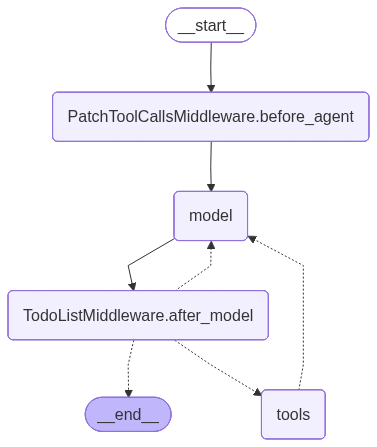

In [ ]:
Image(agent.get_graph().draw_mermaid_png())

**Key takeaway:** `create_deep_agent()` gives you filesystem + planning for free. Files default to **ephemeral agent state** — that `/note.md` vanishes when the thread ends. We fix that in Part 6.

## Part 2: Custom Tools

A research agent needs to find papers. We add two arXiv tools and keep a web-search tool for context arXiv doesn't carry (author/lab background, later coverage). All three are plain Python functions wrapped with `@tool` — see `utils/arxiv_tools.py` and `utils/search.py`.

In [11]:
from langchain.tools import tool
from tavily import TavilyClient

@tool(parse_docstring=True)
def tavily_search(query: str) -> str:
    """Search the web for information on a given query.

    Args:
        query: Search query to execute.
    """
    results = TavilyClient().search(query, max_results=3, topic="general")
    chunks = [
        f"## {r['title']}\n**URL:** {r['url']}\n\n{r.get('content', '')}\n\n---\n"
        for r in results.get("results", [])
    ]
    return f"Found {len(chunks)} result(s) for '{query}':\n\n{''.join(chunks)}"

In [12]:
from utils.arxiv_tools import search_arxiv, get_arxiv_paper

agent = create_deep_agent(
    model=model,
    tools=[search_arxiv, get_arxiv_paper, tavily_search], # add your tools here
    system_prompt="You are a computational-longevity research agent." # define your system prompt here
)

result = agent.invoke({
    "messages": [{"role": "user", "content":
        "Find one arXiv paper on deep-learning aging clocks. One search, then name it and its arXiv id in a sentence."}]
})

print(result["messages"][-1].text)

The paper "Molecule-dynamic-based Aging Clock and Aging Roadmap Forecast with Sundial" (arXiv:2501.02176v1) presents a novel framework for modeling biological aging using deep learning-based molecular dynamics.


**Key takeaway:** the `@tool` decorator turns any function into a LangChain tool; pass them via `tools=[...]`. They sit alongside the built-in filesystem tools.

## Part 3: Understanding Backends

<img src="./images/deepAgentBackends.png" style="width: auto; height: 400px; border-radius: 8px;" alt="Backends">

Where do the agent's files actually go? **Backends** are pluggable storage. The question that matters when choosing one: **who can see the files?**

| Backend | Who can see them | Use case |
|---|---|---|
| **StateBackend** *(default)* | This thread only | Scratch pad, intermediate results |
| **FilesystemBackend** | Anything with disk access | Local projects, sandboxes |
| **StoreBackend** | Any thread in the same namespace | Long-term memory (Part 6) |
| **CompositeBackend** | Depends on the route | Mix backends (Part 6) |

In [13]:
from langgraph.checkpoint.memory import MemorySaver
from langsmith import uuid7

# A checkpointer persists state *within* a thread; thread_id selects the conversation.
checkpointer = MemorySaver()

agent = create_deep_agent(
    model=model,
    tools=[search_arxiv],
    system_prompt="You are a computational-longevity research agent.",
    checkpointer=checkpointer,
)

# This scratch file lives in StateBackend — the default, ephemeral store — so a
# brand-new thread_id would start empty. Part 6 makes a chosen path durable instead.
config1 = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content": "Write /draft.md with 'temporary triage notes'."}]
}, config=config1)
print("thread files:", list((result.get("files") or {}).keys()))

thread files: ['/draft.md']


In [14]:
# The strategy we'll use for the library: route one path to a durable store,
# keep everything else ephemeral.
route_map()

/memories/*,→,StoreBackend,durable · every thread in the namespace
everything else,→,StateBackend,ephemeral · this thread only


**Key takeaway:** choosing a backend is choosing *if files can be seen through threads*. The library needs cross-thread visibility, so in Part 6 we route `/memories/` to a persistent store and leave the rest ephemeral.

### FilesystemBackend — writing to real disk

When the agent should touch **actual files**, use `FilesystemBackend` with `virtual_mode=True`, which sandboxes everything under `root_dir` (always keep it on — it prevents path traversal).

In [15]:
from deepagents.backends import FilesystemBackend
import tempfile, os, shutil

sandbox = tempfile.mkdtemp(prefix="research_sandbox_")   # a sandboxed real directory
fs_agent = create_deep_agent(
    model=model,
    backend=FilesystemBackend(root_dir=sandbox, virtual_mode=True),
    checkpointer=checkpointer,
)

config = {"configurable": {"thread_id": str(uuid7())}}
fs_agent.invoke({
    "messages": [{"role": "user", "content":
        "Write refs.bib with a short example BibTeX @misc entry for an arXiv paper."}]
}, config=config)

with open(os.path.join(sandbox, "refs.bib")) as f:   # it really hit disk
    print(f.read())

shutil.rmtree(sandbox, ignore_errors=True)

@misc{example2023arxiv,
  author = {Author Name},
  title = {Title of the arXiv Paper},
  year = {2023},
  eprint = {2301.00000},
  archivePrefix = {arXiv},
  primaryClass = {cs.LG}
}



## Part 4: Research Subagents

<img src="./images/deepAgentSubagents.png" style="width: auto; height: 380px; border-radius: 8px;" alt="Subagents">

As an agent works, its context fills with intermediate tool calls. **Subagents** run in a *separate* context and return only their final answer — so the main research agent stays focused.

We give the agent **two** specialists and let it coordinate:
- **`search-scout`** — breadth: runs a few arXiv searches and returns a ranked shortlist.
- **`paper-analyst`** — depth: reads one paper and returns a summary, a topic folder, and tags.

Both use the cheaper `sub_agent_model` and inherit the parent's tools. Splitting breadth from depth keeps each context small — and mirrors how you'd actually triage a literature search.

In [17]:
search_scout = {
    "name": "search-scout",
    "description": "Scout arXiv for a topic and return a ranked shortlist. Breadth, not depth.",
    "system_prompt": "Run up to 3 arXiv searches for the topic, then return a ranked shortlist of 3-5 papers (arXiv id, title, one line on relevance). Dedupe. Don't deep-read or file — that's the analyst's job.",
    "model": sub_agent_model,
}

paper_analyst = {
    "name": "paper-analyst",
    "description": "Deep-read one arXiv paper and propose how to file it. One paper at a time.",
    "system_prompt": (
        "You analyze one paper for a longevity library. Use get_arxiv_paper if you need details.\n"
        "Return: a 2-3 sentence summary, a kebab-case topic folder "
        "(e.g. aging-clocks, senescence), and 3-6 lowercase tags. Be concise."
    ),
    "model": sub_agent_model,   # omitting tools for simplicity -> inherits the parent's tools
}

agent = create_deep_agent(
    model=model,
    tools=[search_arxiv, get_arxiv_paper, tavily_search],
    system_prompt=(
        "You are a computational-longevity research agent and coordinator. Delegate breadth (finding papers) to "
        "search-scout and depth (reading one) to paper-analyst; don't do that work inline."
    ),
    subagents=[search_scout, paper_analyst],
    checkpointer=checkpointer,
)

config = {"configurable": {"thread_id": str(uuid7())}}
with trace_link("Part 4 — scout + analyst"):   # 🔗 trace shows the delegation
    result = agent.invoke({
        "messages": [{"role": "user", "content":
            "Scout arXiv for papers on cellular senescence, then have the analyst deep-read the most relevant one."}]
    }, config=config)

print(result["messages"][-1].text)

🔗 Part 4 — scout + analyst: https://smith.langchain.com/o/920d1eb6-2f59-4028-a2ba-13c2b637f463/projects/p/062413e0-03d2-4f32-8875-f604cab210b7/r/019f6ce6-a31d-7ac3-a9bb-0585cf1080d9?poll=true
The search for "cellular senescence" on arXiv primarily yields computational biology papers, as experimental research in this field is typically published in specialized journals.

The most relevant paper identified is **"Predictive landscapes hidden beneath biological cellular automata" (arXiv:2105.01999v2)**.

### Summary of Findings
The paper introduces a method to reduce complex, high-dimensional cellular automata (CA) models of biological systems into low-dimensional dynamical systems using "predictive landscapes." By identifying these landscapes, researchers can model the behavior of complex intracellular networks without needing to know every precise kinetic parameter, which is a significant hurdle in traditional differential equation modeling.

### Relevance to Cellular Senescence
This fra

**Key takeaway:** delegate with `subagents=[...]`. The main agent calls the subagent through a `task()` tool and sees only the result — not the intermediate searches — which keeps its context clean.

## Part 5: Human-in-the-Loop

For sensitive actions, a human should approve before the agent acts. Deep Agents has this built in via `interrupt_on`, with three decision types: **approve · edit · reject**.

We gate `write_file`/`edit_file`, so *nothing lands in the library without sign-off*. A checkpointer is required — the agent has to pause and resume.

In [18]:
show_architecture(through="hitl")

In [19]:
gated = create_deep_agent(
    model=model,
    system_prompt="You are a computational-longevity research agent.",
    checkpointer=checkpointer,
    interrupt_on={
        "write_file": {"allowed_decisions": ["approve", "edit", "reject"]},
        "edit_file": {"allowed_decisions": ["approve", "edit", "reject"]},
    },
)

config = {"configurable": {"thread_id": str(uuid7())}}
result = gated.invoke({
    "messages": [{"role": "user", "content":
        "Write /summary.md with two lines on why aging clocks matter."}]
}, config=config)

# It paused before writing. Look at the one action it's waiting on.
interrupt = result.get("__interrupt__")
if interrupt:
    request = interrupt[0].value["action_requests"][0]
    print("⏸  paused before:", request["name"])
    print(request["args"].get("content", request["args"]))

⏸  paused before: write_file
Aging clocks provide a quantitative measure of biological age, enabling the assessment of interventions that may slow or reverse the aging process.
They serve as critical biomarkers for predicting age-related disease risk and mortality, facilitating personalized health optimization and longevity research.



In [20]:
from langgraph.types import Command

# Approve and let it proceed. (Try {'type': 'reject'} or an 'edit' payload instead.)
if result.get("__interrupt__"):
    result = gated.invoke(
        Command(resume={"decisions": [{"type": "approve"}]}),
        config=config,
    )
    print(result["messages"][-1].text)

print("thread files:", list((result.get("files") or {}).keys()))

The file `/summary.md` has been created with the following content:

Aging clocks provide a quantitative measure of biological age, enabling the assessment of interventions that may slow or reverse the aging process.
They serve as critical biomarkers for predicting age-related disease risk and mortality, facilitating personalized health optimization and longevity research.
thread files: ['/summary.md']


**See the human-in-the-loop node appear in the compiled graph**

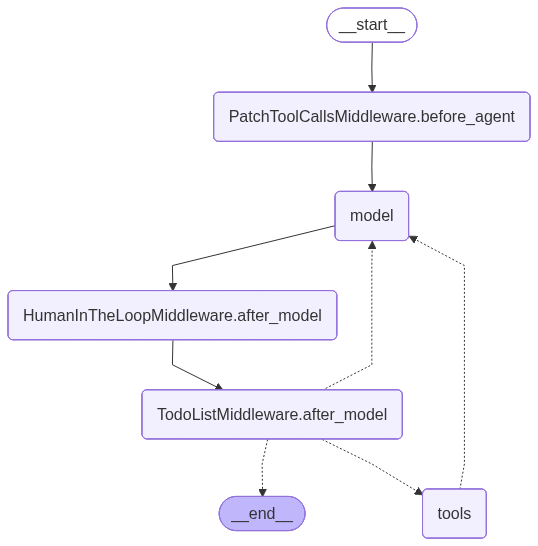

In [21]:
Image(gated.get_graph().draw_mermaid_png()) 

**Key takeaway:** `interrupt_on={...}` gates risky tools. The run returns an `__interrupt__` you inspect, then resume with `Command(resume=...)`. In Part 7 this becomes the gate on the library itself.

## Part 6: Long-Term Memory  ⭐

<img src="./images/deepAgentMemories.png" style="width: auto; height: 380px; border-radius: 8px;" alt="Long-term memory">

This is the point of the whole thing. Files in `StateBackend` die with the thread. **Long-term memory** uses `CompositeBackend` to route one path to a persistent `StoreBackend`:

```
/memories/*       →  StoreBackend   (durable, cross-thread — SQLite on disk)
everything else   →  StateBackend   (ephemeral)
```

We back the store with a real SQLite file (`library_memory.db`), so the library survives a kernel restart. Watch the visualizers: `show_memory` reads the store **directly**, so it's ground truth, not thread state.

In [22]:
show_architecture(through="memory")

In [23]:
from deepagents.backends import StateBackend, StoreBackend, CompositeBackend

store = open_memory_store()   # SQLite on disk: library_memory.db

backend = CompositeBackend(
    default=StateBackend(),                                      # ephemeral
    routes={"/memories/": StoreBackend(store=store,             # durable
                                       namespace=lambda rt: MEMORY_NAMESPACE)},
)

agent = create_deep_agent(
    model=model,
    tools=[search_arxiv, get_arxiv_paper, tavily_search],
    subagents=[search_scout, paper_analyst],
    system_prompt=(
        "You are a computational-longevity research agent with a persistent library at /memories/library/.\n"
        "File each paper as a markdown entry in /memories/library/<topic>.md. "
        "Check the library before searching so you never re-file a paper."
    ),
    backend=backend,
    store=store,
    checkpointer=checkpointer,
)

before = snapshot(store)   # freeze the library so we can diff what changes

# Thread 1: find and file a paper
config1 = {"configurable": {"thread_id": str(uuid7())}}
with trace_link("Part 6 — file a paper"):
    result = agent.invoke({
        "messages": [{"role": "user", "content":
            "Find one well-known arXiv paper on epigenetic aging clocks and file it under "
            "/memories/library/aging-clocks.md. One search."}]
    }, config=config1)
print(result["messages"][-1].text)

# The thread's own filesystem stays essentially empty — the paper went to the store.
print("thread files (ephemeral):", list((result.get("files") or {}).keys()))
render_diff(before, snapshot(store))
show_memory(store)

🔗 Part 6 — file a paper: https://smith.langchain.com/o/920d1eb6-2f59-4028-a2ba-13c2b637f463/projects/p/062413e0-03d2-4f32-8875-f604cab210b7/r/019f6ce7-e1f7-7ae3-b8d7-153f4cd82be0?poll=true
The paper "Aggregating Epigenetic Clocks to Study Human Capital Formation" (arXiv:2509.14422v1) has been filed under `/memories/library/aging-clocks.md`.
thread files (ephemeral): []


In [24]:
# Thread 2: a brand-new conversation. The library persists across threads.
config2 = {"configurable": {"thread_id": str(uuid7())}}

result = agent.invoke({
    "messages": [{"role": "user", "content": "What papers do I have on aging clocks? Check the library."}]
}, config=config2)

print("Thread 2 (new thread):", result["messages"][-1].text)

Thread 2 (new thread): You have one paper filed in your library under `aging-clocks.md`:

**Aggregating Epigenetic Clocks to Study Human Capital Formation**
*   **ID**: 2509.14422v1
*   **Authors**: Giorgia Menta, Pietro Biroli, Divya Mehta, Conchita D'Ambrosio, Deborah Cobb-Clark
*   **Published**: 2025-09-17
*   **Summary**: This paper introduces the "Multi EpiGenetic Age" (MEGA) clock, which aggregates several existing epigenetic clocks to reduce measurement error. The authors demonstrate its utility by linking accelerated epigenetic aging in adolescence to various socioeconomic and health outcomes, and by showing the impact of childhood maltreatment and school entry timing on biological aging.


### It's really on disk

The library isn't in this process — it's in `deep_agents_memory.db`. Re-open the **same database from scratch** (as if the kernel had restarted) and it's all still there. To prove it hard: restart the kernel, run **only the Part 0 imports cell** (*not* the optional reset cell), then run the cell below.

In [25]:
reopened = open_memory_store()   # same file, fresh connection
show_memory(reopened)
show_library(reopened)

**Key takeaway:** `CompositeBackend` + a persistent `store=` gives you memory that outlives the thread *and* the process. The agent reaches it through ordinary file paths under `/memories/`; you can inspect it directly through the store.

## Part 7: AGENTS.md & Skills — the complete agent

So far, instructions lived in `system_prompt`. Two file-based alternatives are more powerful:

| Approach | Loaded when | Editable by agent | Best for |
|---|---|---|---|
| `system_prompt` | Always | No | Core identity, immutable rules |
| `AGENTS.md` (`memory=`) | Always | **Yes** | Workflow, learnable rules |
| `SKILL.md` (`skills=`) | On demand | No | Task-specific templates |

- **`AGENTS.md`** loads into the system prompt via `memory=`; the agent can read and edit it.
- **Skills** use **progressive disclosure**: only each skill's name + description loads at startup; the full `SKILL.md` is read on demand.

We point the **default backend at the `agent/` folder** (a `FilesystemBackend`), so `AGENTS.md` and `skills/` load straight from disk — the same identity `agent/agent.py` uses when deployed. `/memories/` still routes to the durable store.

In [26]:
show_architecture(through="skills", store=store)

**Auto-approve helper.** Part 5 resumed one pause by hand; here's the same `Command(resume=...)`, looped, so we can approve every pause and keep moving.

In [27]:
from langgraph.types import Command

def approve_all(agent, result, config):
    """Approve every HITL pause until the agent finishes."""
    while result.get("__interrupt__"):
        actions = result["__interrupt__"][0].value["action_requests"]
        for a in actions:
            print(f"⏸  approving {a['name']} -> {a['args'].get('file_path', '?')}")
        result = agent.invoke(
            Command(resume={"decisions": [{"type": "approve"} for _ in actions]}),
            config=config,
        )
    return result

In [28]:
from deepagents.backends import FilesystemBackend

# Default backend = the agent/ folder on real disk, so AGENTS.md and skills/ load
# from there directly (no seeding). /memories/ still routes to the durable store.
backend = CompositeBackend(
    default=FilesystemBackend(root_dir="agent", virtual_mode=True),
    routes={"/memories/": StoreBackend(store=store, namespace=lambda rt: MEMORY_NAMESPACE)},
)

agent = create_deep_agent(
    model=model,
    tools=[search_arxiv, get_arxiv_paper, tavily_search],
    subagents=[search_scout, paper_analyst],
    memory=["./AGENTS.md"],     # agent/AGENTS.md — always loaded into the system prompt
    skills=["./skills/"],       # agent/skills/*  — loaded on demand
    backend=backend,
    store=store,
    checkpointer=checkpointer,
    interrupt_on={
        "write_file": {"allowed_decisions": ["approve", "edit", "reject"]},
        "edit_file": {"allowed_decisions": ["approve", "edit", "reject"]},
    },
)

print("Complete research agent ready: memory + 2 subagents + HITL + AGENTS.md + skills")

Complete research agent ready: memory + 2 subagents + HITL + AGENTS.md + skills


**The graph grew.** Same `create_deep_agent()`, but HITL + memory + skills each add middleware — every capability is now a node in the compiled graph:

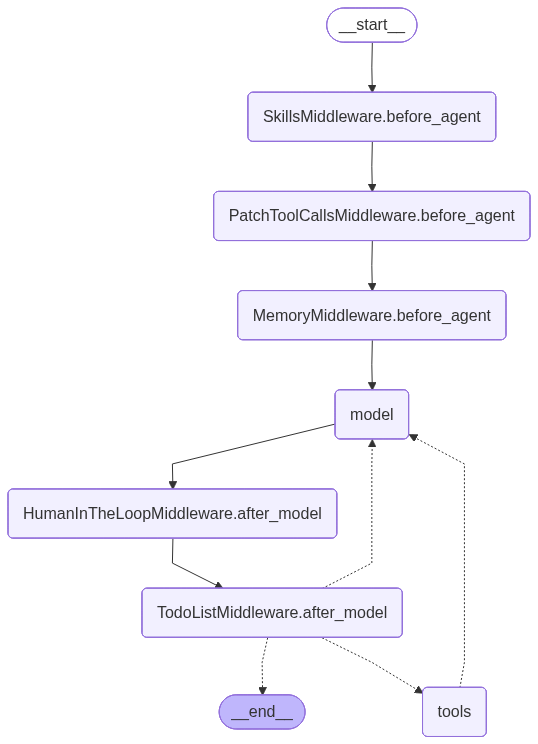

In [29]:
Image(agent.get_graph().draw_mermaid_png())

In [30]:
# File a second paper — this time gated by human approval.
before = snapshot(store)
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content":
        "Find one arXiv paper on cellular senescence and file it in the library. One search."}]
}, config=config)

result = approve_all(agent, result, config)   # inspect the pauses, then approve
print(result["messages"][-1].text)

# Exactly what the approved write added to memory:
render_diff(before, snapshot(store))
show_library(store)

⏸  approving write_file -> /memories/library/senescence.md
I have filed the paper "Network-community analysis of cellular senescence" (arXiv:2406.13889) in the new `/memories/library/senescence.md` file.


**Key takeaway:** `AGENTS.md` is an editable identity that's always loaded; skills are templates loaded only when relevant. Together with memory + HITL, that's the full agent — the same one wired up in `agent/agent.py`.

## Part 8: The Podcast — Episodes with Memory

The payoff. NotebookLM's **Audio Overview** turns documents into a two-host podcast, no code required — we just hand it good material. The twist: we treat the podcast as a **series**. Every episode is logged to `/memories/podcast_log.md`, so the next one covers only the papers that are new since last time. Continuity, powered by the same long-term memory that holds the library.

In [32]:
# Generate the next episode. The agent checks the episode log, covers only
# papers not yet aired, writes the briefing, and records the episode in memory —
# guided by the paper-podcast skill. Each write pauses for approval.
before = snapshot(store)
config = {"configurable": {"thread_id": str(uuid7())}}
with trace_link("Episode 1"):
    result = agent.invoke({
        "messages": [{"role": "user", "content":
            "Generate the next podcast episode from my library using the paper-podcast skill: "
            "check the episode log, cover the papers not yet covered, write the briefing to "
            "/briefing.md, and record the episode in /memories/podcast_log.md."}]
    }, config=config)
    result = approve_all(agent, result, config)
print(result["messages"][-1].text)

save_briefing("agent/briefing.md", "episode_1_briefing.md")

# The episode is now recorded in long-term memory — that's the continuity.
render_diff(before, snapshot(store))
show_memory(store)

⏸  approving edit_file -> /memories/library/aging-clocks.md
⏸  approving write_file -> /briefing.md
⏸  approving edit_file -> /briefing.md
⏸  approving edit_file -> /memories/podcast_log.md
🔗 Episode 1: https://smith.langchain.com/o/920d1eb6-2f59-4028-a2ba-13c2b637f463/projects/p/062413e0-03d2-4f32-8875-f604cab210b7/r/019f6cea-aa9b-7ac3-82cc-28099c4dbe99?poll=true
All papers currently in your library were covered in the first episode. As per the `paper-podcast` skill instructions, I have generated a bridge episode briefing in `/briefing.md` and updated the `/memories/podcast_log.md` to reflect that no new papers were covered in Episode 2.


AttributeError: 'str' object has no attribute 'get'

### Turn it into a podcast

Upload a briefing and let NotebookLM voice it:

1. Open **[notebooklm.google.com](https://notebooklm.google.com)** → new notebook.
2. **Add source** → upload `episode_1_briefing.md`.
3. **Studio → Audio Overview → Generate** (use **Customize** to steer or shorten it).
4. Play it, or **download** from the **⋮** menu.

### Episode 2 — the memory pays off

Continuity is the whole point. File **one more paper**, then ask for the next episode: because Episode 1 is logged in `/memories/podcast_log.md`, the podcast picks up where it left off and Episode 2 covers **only the new paper**.

In [33]:
# File one more paper on a fresh topic — gated by approval, like before.
before = snapshot(store)
config = {"configurable": {"thread_id": str(uuid7())}}
result = agent.invoke({
    "messages": [{"role": "user", "content":
        "Find one arXiv paper on caloric restriction and metabolism, and file it in the library. One search."}]
}, config=config)

result = approve_all(agent, result, config)
print(result["messages"][-1].text)
render_diff(before, snapshot(store))
show_library(store)

⏸  approving write_file -> /memories/library/nonequilibrium-thermodynamics-of-aging.md
I have filed the following paper in the library under a new topic file, `/memories/library/nonequilibrium-thermodynamics-of-aging.md`:

**A Nonequilibrium Internal-Time Model of Aging: Entropy-Normalized Biological Proper Time and Repair Bifurcations**
*   **arXiv ID:** 2606.23279
*   **Summary:** This paper proposes a thermodynamic framework for aging, defining biological age as an "internal-time" coordinate based on the accumulation of entropy-normalized physiological cycles. It suggests that interventions like caloric restriction can slow aging by reducing the entropy cost per biological cycle.


In [34]:
# Ask for the NEXT episode. The paper-podcast skill reads /memories/podcast_log.md,
# sees Episode 1 already aired, and covers only the newly-filed paper.
before = snapshot(store)
config = {"configurable": {"thread_id": str(uuid7())}}
with trace_link("Episode 2"):
    result = agent.invoke({
        "messages": [{"role": "user", "content":
            "Generate the next podcast episode using the paper-podcast skill: check the episode "
            "log, cover only the papers not yet aired, write the briefing to /briefing.md, and "
            "record the episode in /memories/podcast_log.md."}]
    }, config=config)
    result = approve_all(agent, result, config)
print(result["messages"][-1].text)

save_briefing("agent/briefing.md", "episode_2_briefing.md")

# The log now holds BOTH episodes — continuity backed by long-term memory.
render_diff(before, snapshot(store))
show_memory(store)

⏸  approving write_file -> /briefing.md
⏸  approving edit_file -> /briefing.md
⏸  approving edit_file -> /memories/podcast_log.md
🔗 Episode 2: https://smith.langchain.com/o/920d1eb6-2f59-4028-a2ba-13c2b637f463/projects/p/062413e0-03d2-4f32-8875-f604cab210b7/r/019f6cec-88a7-7973-a205-15e3106ea4a6?poll=true
The next podcast episode (Episode 3) has been generated and logged.

- **Briefing**: Updated in `/briefing.md`.
- **Log**: Recorded in `/memories/podcast_log.md`.

This episode covers:
1. **Nonequilibrium Thermodynamics of Aging**: Taye (2026) on entropy-normalized biological time and caloric restriction.
2. **Cellular Senescence**: Sabalic et al. (2024) on network-community analysis of transcriptional markers.
3. **Epigenetic Clocks**: Menta et al. (2025) on the Multi EpiGenetic Age (MEGA) clock.


AttributeError: 'str' object has no attribute 'get'

## Part 9: Wrap-Up & Next Steps

Starting from a bare `create_deep_agent()`, we layered on:

```
Part 1: create_deep_agent(model)            -> filesystem + planning
Part 2: + tools=[search_arxiv, ...]         -> arXiv + web search
Part 3: (backends)                          -> who can see the files
Part 4: + subagents=[scout, analyst]        -> context isolation
Part 5: + interrupt_on={...}                -> human approval
Part 6: + CompositeBackend + SqliteStore    -> durable, cross-thread memory
Part 7: + memory=AGENTS.md + skills=        -> editable identity + on-demand skills
Part 8: episode briefing + /memories log    -> a podcast series with continuity
```

### Run it as a live app
`agent/agent.py` packages this same agent as a graph — run `uv run langgraph dev` and open it in [agentchat](https://agentchat.vercel.app) (exact URL in the README). You'll get the approve/edit/reject prompt in the UI, and the library persists across threads.

### Try next
1. **Per-user memory** — swap `("library", "shared")` for `("library", user_id)` in `utils/memory.py`.
2. **More skills** — add a `SKILL.md` for your own output formats.
3. **A cheaper subagent** — point `sub_agent_model` at a different tier.

### Resources
- [Deep Agents docs](https://docs.langchain.com/oss/python/deepagents/)
- [LangChain Academy](https://academy.langchain.com/)

---

**Happy podcasting!** 🎙️